# CREDIT CARD CUSTOMER CHURN ANALYSIS
## ADVANCED EXPLORATORY ANALYSIS

This will explore the churn pattern accross demographic, behaviours and financial dimension to gain insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


In [2]:
# Load the cleaned dataset
df_BankChurn = pd.read_csv("../DataSet/Cleaned/BankChurners_Cleaned.csv")   
df_BankChurn.shape

(10127, 28)

In [3]:
# Churcn Distribution
df_BankChurn["Churn_Flag"].value_counts()   


Churn_Flag
0    8500
1    1627
Name: count, dtype: int64

In [4]:
(df_BankChurn["Churn_Flag"].value_counts(normalize=True) * 100).round(2) # calculating the percentage of churners and non-churners in the dataset, and rounded to 2 decimal places


Churn_Flag
0    83.93
1    16.07
Name: proportion, dtype: float64

## Churn Distribution Insight
It shows that 16.1% of the customers have churned while 83.93% remain active. Although the majority of the customer are still existing, the churn proportion is a significant revenue risk which needs further investigation into the drivers of the attrition.

In [15]:
# Churn by Gender crosstab
churn_gender = pd.crosstab(df_BankChurn["Gender"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_gender.round(2)   


Churn_Flag,0,1
Gender,,
F,82.64,17.36
M,85.38,14.62


## Churn by Gender Insight
I observed that female customers have a slightly higher churn rate than male customers.

While the gap is not very large, it highlights a possible difference in customer experience or engagement levels. This insight could be useful when developing targeted retention campaigns.

In [16]:
# Churn by Age Band crosstab
churn_age = pd.crosstab(df_BankChurn["Age_Band"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_age.round(2)

Churn_Flag,0,1
Age_Band,,
18-30,87.92,12.08
31-40,85.46,14.54
41-50,83.25,16.75
51-60,83.24,16.76
60+,85.68,14.32


## Churn by Age Band Insight
From the Analysis, churns appear to increase as customer get older before dropping slighly after 60. 
Customer between 41 and 60 years show the highest churn levels, while Younger customers are more likely to stay.

In [17]:
# Churn by Tenure Band crosstab
churn_tenure = pd.crosstab(df_BankChurn["Tenure_Band"], df_BankChurn["Churn_Flag"], normalize="index") * 100
churn_tenure.round(2)

Churn_Flag,0,1
Tenure_Band,,
1-2 years,85.12,14.88
2-3 years,83.92,16.08
3-4 years,83.82,16.18
4+ years,83.05,16.95


## Churn by Tenure Band Insight
The analysis shows that churn increases as customer tenure increases.
Customers who have been with the bank for 1–2 years have the lowest churn rate (14.88%), while those with over 4 years of tenure have the highest churn rate (16.95%).
This may indicate declining satisfaction,or may be attracted by better offers from competitors.


### Demographic Churn Summary
Demographic analysis shows that churn varies across different customer groups.
Female customers have a slightly higher churn rate compared to male customers.
Churn increases with age, with customers aged 41–60 showing the highest attrition levels.
Tenure analysis also reveals that long-term customers are more likely to churn than newer customers.


In [18]:
# Activity_Level by Churn crosstab
activity_churn = pd.crosstab(df_BankChurn["Activity_Level"], df_BankChurn["Churn_Flag"], normalize="index") * 100
activity_churn.round(2)

Churn_Flag,0,1
Activity_Level,,
High,98.78,1.22
Low,68.47,31.53
Medium,82.53,17.47


## Activity Level by Churn Insight
From the analysis, customer activity has a strong relationship with churn.
Customer who use their card more tend to stay, while those who use them less are more likely to churn.
Low activity customers represent the highest risk group for attrition. 


In [21]:
# Utilisation by Churn crosstab
utilisation_churn = pd.crosstab(df_BankChurn["Utilisation_Segment"], df_BankChurn["Churn_Flag"], normalize="index") * 100
utilisation_churn.round(2)

Churn_Flag,0,1
Utilisation_Segment,,
High,87.06,12.94
Low,79.56,20.44
Medium,92.47,7.53


## Utilisation by Churn Insight
The analysis show that customer with low credit utilisation have the highest churn rate (20%). Customer with medium utilisation have the lowest churn rate about(8%). 
This suggests that customers who rarely use their credit cards are more likely to leave the bank.

In [22]:
# Spend Drop by Churn crosstab
spend_churn = pd.crosstab(df_BankChurn["Spend_Drop_Flag"], df_BankChurn["Churn_Flag"], normalize="index") * 100 
spend_churn.round(2)    

Churn_Flag,0,1
Spend_Drop_Flag,,
0,85.80,14.20
1,83.73,16.27


## Spend Drop by Churn Insight
From teh analysis, customers whose spending dropped from Q4 to Q1 show a slighly higher churn rate (16.27%), compare to those whose spending do not drop (14.20%).
However the difference is small, so spending drop alone may not strongly predict attrition.


In [25]:
# Transaction Drop by Churn crosstab
transaction_churn = pd.crosstab(df_BankChurn["Transaction_Drop_Flag"], df_BankChurn["Churn_Flag"], normalize="index") * 100
transaction_churn.round(2)  

Churn_Flag,0,1
Transaction_Drop_Flag,,
0,92.93,7.07
1,83.13,16.87


## Transaction Drop by Churn Insight
Customer whose transaction activity dropped show a higher churn rate (16.87%), compared to those whose transactions did not drop (7.07%).
This suggests that declining card usage is a strong indicator of disengagement and warning sign for attrition.

### Behavioural Churn Summary
Behavioural features show the strongest relationship with churn.
Low activity customers show the highest churn risks, followed by low credit utilisation transaction drop frequency.
Spend Drop shows a small but still noticeable relationship with attrition

## Generate Correlation Heatmap
This will help to identify which numerical features relates to churn, strong predictors for modelling.


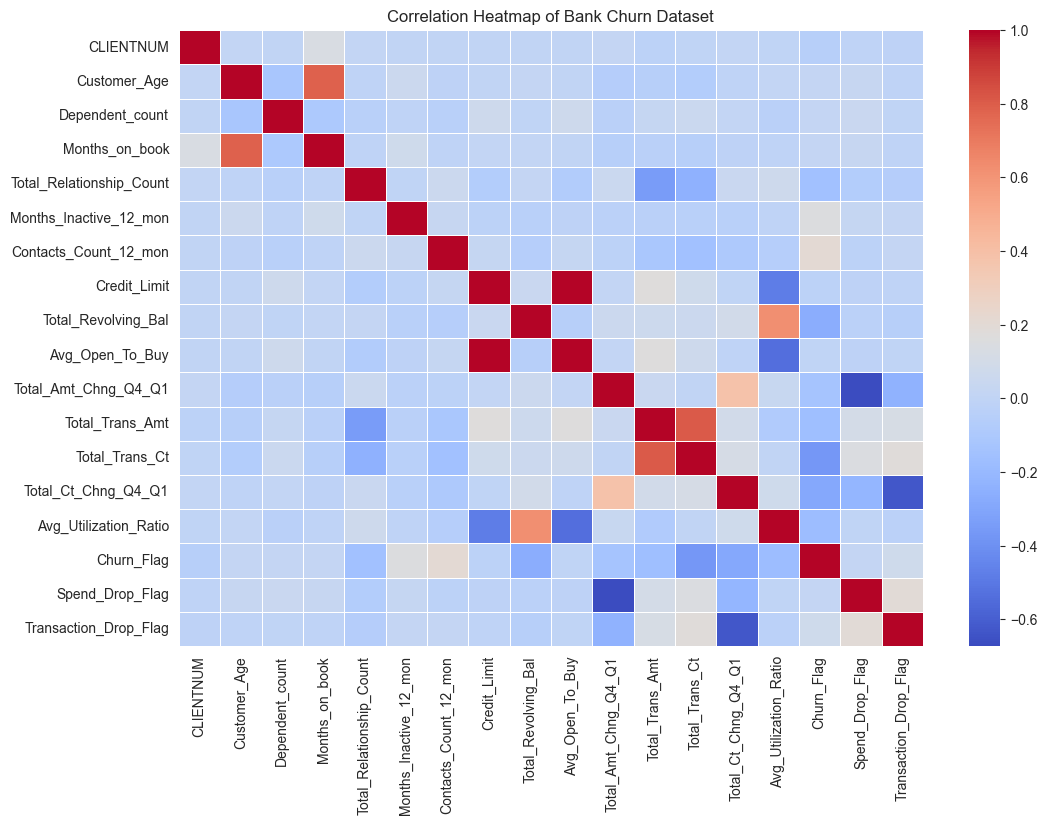

In [26]:
# Creating a correlation Heatmap
plt.figure(figsize=(12, 8)) 
sns.heatmap(df_BankChurn.corr(numeric_only=True), cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap of Bank Churn Dataset")    
plt.show()  

In [ ]:
# Focused Churn Correlation Heatmap

churn_corr = (df_BankChurn.corr(numeric_only=True)["Churn_Flag"].sort_values(ascending=False))
churn_corr 

Churn_Flag                  1.000000
Contacts_Count_12_mon       0.204491
Months_Inactive_12_mon      0.152449
Transaction_Drop_Flag       0.073353
Dependent_count             0.018991
Customer_Age                0.018203
Spend_Drop_Flag             0.016820
Months_on_book              0.013687
Avg_Open_To_Buy            -0.000285
Credit_Limit               -0.023873
CLIENTNUM                  -0.046430
Total_Amt_Chng_Q4_Q1       -0.131063
Total_Relationship_Count   -0.150005
Total_Trans_Amt            -0.168598
Avg_Utilization_Ratio      -0.178410
Total_Revolving_Bal        -0.263053
Total_Ct_Chng_Q4_Q1        -0.290054
Total_Trans_Ct             -0.371403
Name: Churn_Flag, dtype: float64

<Figure size 1000x600 with 0 Axes>